<a href="https://colab.research.google.com/github/ARehman007-max/internship/blob/main/Assig3_Customer_Churn_Prediction_with_a_Tuned_Neural_Network_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload the Telco Customer Churn CSV file:


Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (5).csv

 Dataset loaded successfully!
Dataset shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Column types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values check:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Paperles

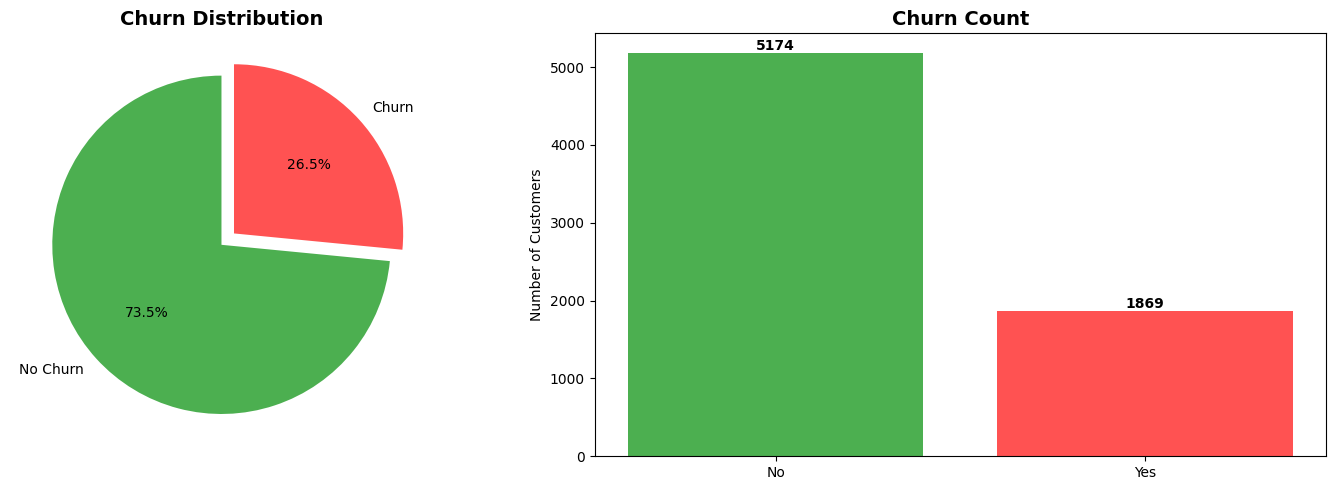

<Figure size 1200x600 with 0 Axes>

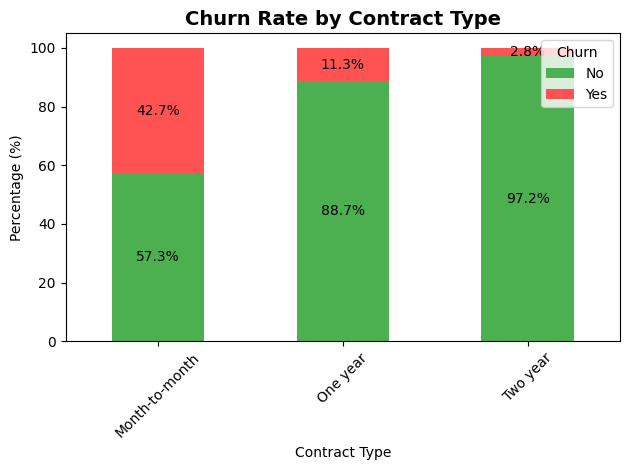

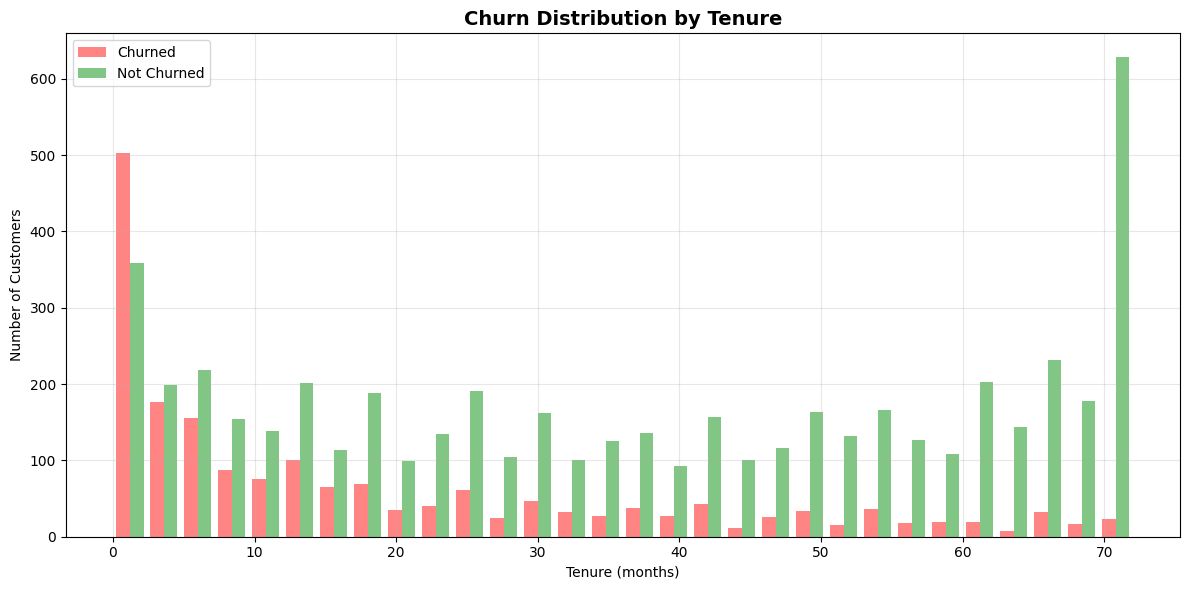


 Part 1 Complete: Data loaded, cleaned, and explored!


In [9]:
# ============================================
# ASSIGNMENT 3: Telco Customer Churn Prediction
# PART 1: Setup, Data Loading, and Exploration
# ============================================

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping
import io
from google.colab import files

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Upload dataset
print("Please upload the Telco Customer Churn CSV file:")
uploaded = files.upload()

# Get the filename from the uploaded dictionary to handle variations in filename
filename = list(uploaded.keys())[0]

# Load the dataset
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print("\n Dataset loaded successfully!")
print("="*60)
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())
print("\nColumn types:")
print(df.dtypes)
print("\nMissing values check:")
print(df.isnull().sum())

# Handle TotalCharges - convert to numeric, handle blank entries
print("\n" + "="*60)
print("DATA CLEANING")
print("="*60)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Missing values in TotalCharges after conversion: {df['TotalCharges'].isnull().sum()}")

# Fill missing TotalCharges with MonthlyCharges (for tenure 0 customers)
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])
print(f"Missing values after filling: {df['TotalCharges'].isnull().sum()}")

# Drop customerID as it's not useful for prediction
df = df.drop('customerID', axis=1)
print(f"Shape after dropping customerID: {df.shape}")

# Check churn distribution
print("\n" + "="*60)
print("CHURN ANALYSIS")
print("="*60)
churn_counts = df['Churn'].value_counts()
print("\nChurn distribution:")
print(churn_counts)
print(f"\nChurn percentage: {(churn_counts['Yes']/len(df))*100:.2f}%")
print(f"Class imbalance: The dataset is IMBALANCED with majority class being 'No Churn'")

# Visualize churn distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Pie chart
axes[0].pie(churn_counts.values, labels=['No Churn', 'Churn'],
            autopct='%1.1f%%', colors=['#4CAF50', '#FF5252'], startangle=90,
            explode=(0, 0.1))
axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[1].bar(churn_counts.index, churn_counts.values, color=['#4CAF50', '#FF5252'])
axes[1].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Customers')
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Visualize churn vs contract type
plt.figure(figsize=(12, 6))
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
ax = contract_churn.plot(kind='bar', stacked=True, color=['#4CAF50', '#FF5252'])
plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Percentage (%)')
plt.legend(title='Churn', loc='upper right')
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')
plt.tight_layout()
plt.show()

# Visualize churn vs tenure
plt.figure(figsize=(12, 6))
tenure_churned = df[df['Churn'] == 'Yes']['tenure']
tenure_not_churned = df[df['Churn'] == 'No']['tenure']
plt.hist([tenure_churned, tenure_not_churned], bins=30, label=['Churned', 'Not Churned'],
         color=['#FF5252', '#4CAF50'], alpha=0.7)
plt.title('Churn Distribution by Tenure', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n Part 1 Complete: Data loaded, cleaned, and explored!")


PART 2: DATA PREPROCESSING

Categorical columns: ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
Numerical columns: ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges']

 Binary encoded columns: ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
   Justification: These columns have only 2 categories (Yes/No), so binary encoding saves dimensions

 One-hot encoded columns: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod', 'gender']
   Justification for InternetService encoding:
   - InternetService has 3 categories: DSL, Fiber optic, No
   - These categories have no inherent order (ordinal relationship)
   - One-hot encoding creates binary columns for each categ

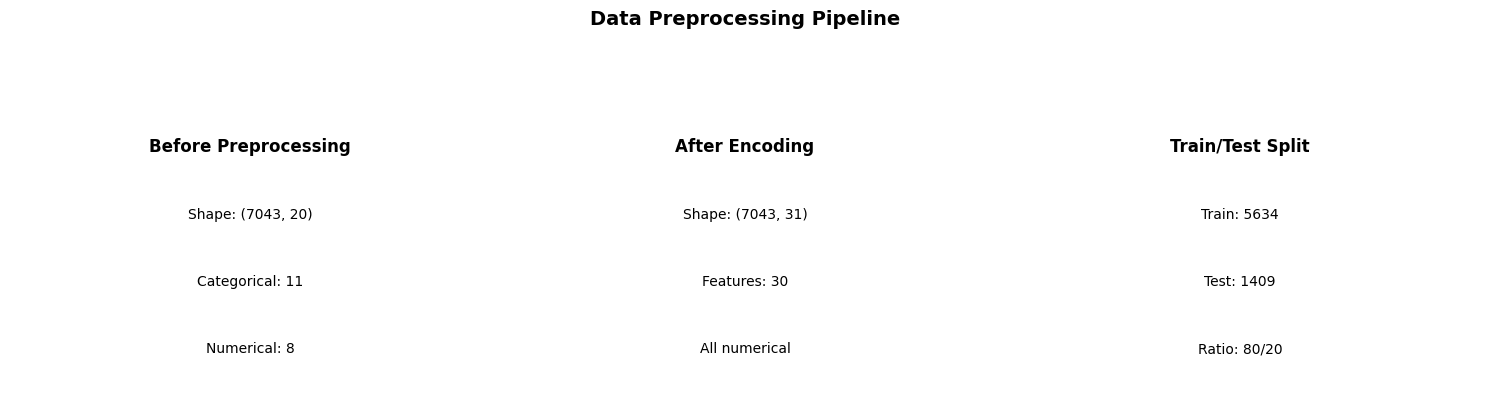


 Part 2 Complete: Data preprocessed and ready for modeling!


In [11]:
# ============================================
# PART 2: Data Preprocessing for Neural Network
# ============================================

print("\n" + "="*60)
print("PART 2: DATA PREPROCESSING")
print("="*60)

# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('Churn')  # Remove target variable
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nCategorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

# Binary encoding for Yes/No columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = (df[col] == 'Yes').astype(int)
print(f"\n Binary encoded columns: {binary_cols}")
print("   Justification: These columns have only 2 categories (Yes/No), so binary encoding saves dimensions")

# One-hot encoding for multi-category columns
multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                  'Contract', 'PaymentMethod', 'gender']

print(f"\n One-hot encoded columns: {multi_cat_cols}")
print("""   Justification for InternetService encoding:
   - InternetService has 3 categories: DSL, Fiber optic, No
   - These categories have no inherent order (ordinal relationship)
   - One-hot encoding creates binary columns for each category
   - This prevents the model from assuming 'DSL' > 'Fiber optic' or similar
   - Example: InternetService_DSL, InternetService_Fiber_optic columns created""")

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

# Encode target variable
df_encoded['Churn'] = (df_encoded['Churn'] == 'Yes').astype(int)
print("\n Target variable 'Churn' encoded: Yes=1, No=0")

# Split features and target
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Scale numerical features
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])
print(f"\n Scaled numerical features: {numerical_cols}")
print("   Using StandardScaler to normalize features to mean=0, std=1")

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)
print(f"\n Data split complete:")
print(f"   Training set: {X_train.shape[0]} samples")
print(f"   Test set: {X_test.shape[0]} samples")
print(f"   Feature count: {X_train.shape[1]} features")

# Visualize the preprocessing steps
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Before encoding
axes[0].text(0.5, 0.7, 'Before Preprocessing', ha='center', fontsize=12, fontweight='bold')
axes[0].text(0.5, 0.5, f'Shape: {df.shape}', ha='center', fontsize=10)
axes[0].text(0.5, 0.3, f'Categorical: {len(categorical_cols)}', ha='center', fontsize=10)
axes[0].text(0.5, 0.1, f'Numerical: {len(numerical_cols)}', ha='center', fontsize=10)
axes[0].axis('off')

# After encoding
axes[1].text(0.5, 0.7, 'After Encoding', ha='center', fontsize=12, fontweight='bold')
axes[1].text(0.5, 0.5, f'Shape: {df_encoded.shape}', ha='center', fontsize=10)
axes[1].text(0.5, 0.3, f'Features: {X.shape[1]}', ha='center', fontsize=10)
axes[1].text(0.5, 0.1, 'All numerical', ha='center', fontsize=10)
axes[1].axis('off')

# Train/Test split
axes[2].text(0.5, 0.7, 'Train/Test Split', ha='center', fontsize=12, fontweight='bold')
axes[2].text(0.5, 0.5, f'Train: {X_train.shape[0]}', ha='center', fontsize=10)
axes[2].text(0.5, 0.3, f'Test: {X_test.shape[0]}', ha='center', fontsize=10)
axes[2].text(0.5, 0.1, f'Ratio: 80/20', ha='center', fontsize=10)
axes[2].axis('off')

plt.suptitle('Data Preprocessing Pipeline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Part 2 Complete: Data preprocessed and ready for modeling!")


PART 3: BASELINE NEURAL NETWORK MODEL

 Baseline Model Architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_3 (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)


 Training Baseline Model...
Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7582 - loss: 0.4919 - val_accuracy: 0.7737 - val_loss: 0.4510
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8032 - loss: 0.4209 - val_accuracy: 0.7684 - val_loss: 0.4489
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8059 - loss: 0.4144 - val_accuracy: 0.7720 - val_loss: 0.4497
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8074 - loss: 0.4101 - val_accuracy: 0.7746 - val_loss: 0.4491
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8087 - loss: 0.4064 - val_accuracy: 0.7755 - val_loss: 0.4486
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8096 - loss: 0.4034 - val_accuracy: 0.7764 - val_loss: 0.4492
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8094 - loss: 0.4009 - val_accuracy: 0.7737 - val_loss: 0.4510
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8103 - l

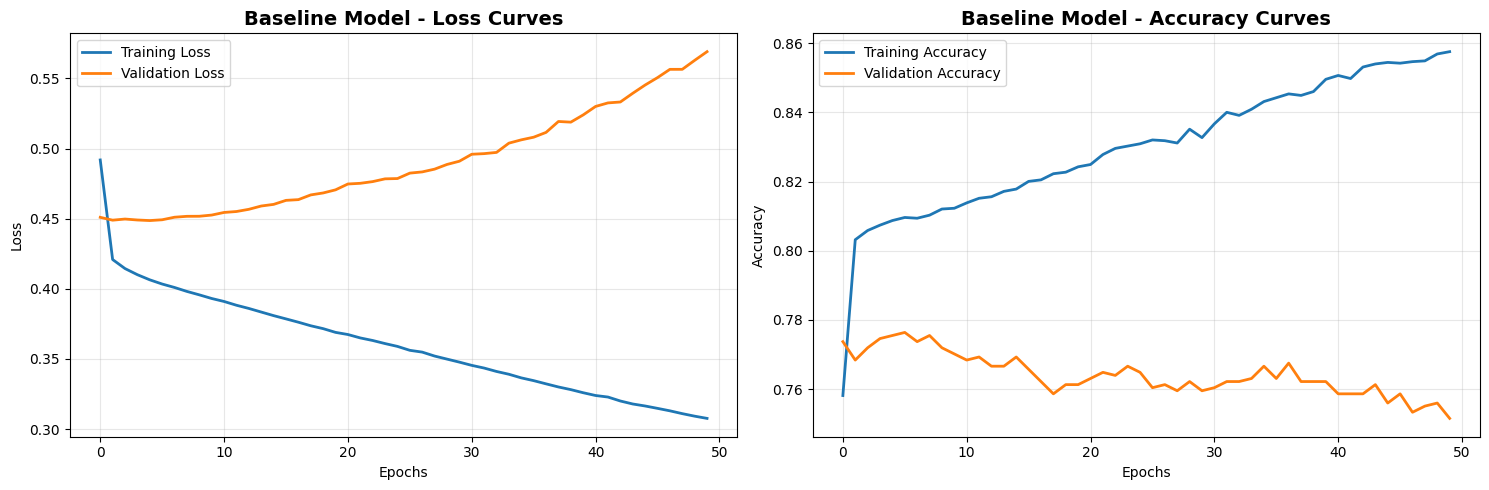


 Part 3 Complete: Baseline model trained and evaluated!


In [12]:
# ============================================
# PART 3: Build & Train Baseline Model
# ============================================

print("\n" + "="*60)
print("PART 3: BASELINE NEURAL NETWORK MODEL")
print("="*60)

def create_baseline_model(input_dim):
    """
    Create baseline neural network model
    Architecture: 3 hidden layers with ReLU activation
    """
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(input_dim,), name='Hidden_Layer_1'),
        layers.Dense(32, activation='relu', name='Hidden_Layer_2'),
        layers.Dense(16, activation='relu', name='Hidden_Layer_3'),
        layers.Dense(1, activation='sigmoid', name='Output_Layer')
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Create baseline model
baseline_model = create_baseline_model(X_train.shape[1])
print("\n Baseline Model Architecture:")
print("="*50)
baseline_model.summary()

# Train baseline model
print("\n Training Baseline Model...")
baseline_history = baseline_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate baseline model
baseline_test_loss, baseline_test_acc = baseline_model.evaluate(X_test, y_test, verbose=0)
print("\n" + "="*50)
print(" BASELINE MODEL PERFORMANCE:")
print("="*50)
print(f" Test Accuracy: {baseline_test_acc:.4f} ({baseline_test_acc*100:.2f}%)")
print(f" Test Loss: {baseline_test_loss:.4f}")

# Plot baseline training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss curves
axes[0].plot(baseline_history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(baseline_history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Baseline Model - Loss Curves', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(baseline_history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(baseline_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('Baseline Model - Accuracy Curves', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Part 3 Complete: Baseline model trained and evaluated!")


PART 4: MODEL TUNING & IMPROVEMENT

 Tuning Techniques Applied:
1. Dropout (0.3, 0.3, 0.2) - Prevents overfitting by randomly dropping neurons
2. Batch Normalization - Normalizes layer inputs for faster training
3. L2 Regularization (0.001) - Penalizes large weights to reduce overfitting
4. Early Stopping (patience=10) - Stops training when validation loss stops improving
5. Increased neurons (128, 64, 32) - More capacity for learning complex patterns


 Tuned Model Architecture:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Dense_1 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_1                     │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_2                     │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_3                     │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,233 (59.50 KB)

 Trainable params: 14,785 (57.75 KB)

 Non-trainable params: 448 (1.75 KB)


 Training Tuned Model...
Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.6814 - loss: 0.7918 - val_accuracy: 0.8048 - val_loss: 0.6680
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7619 - loss: 0.6593 - val_accuracy: 0.8021 - val_loss: 0.6123
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7837 - loss: 0.6190 - val_accuracy: 0.7924 - val_loss: 0.5956
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7872 - loss: 0.6013 - val_accuracy: 0.7862 - val_loss: 0.5900
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7897 - loss: 0.5777 - val_accuracy: 0.7870 - val_loss: 0.5817
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7928 - loss: 0.5692 - val_accuracy: 0.7888 - val_loss: 0.5712
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7901 - loss: 0.5584 - val_accuracy: 0.7924 - val_loss: 0.5621
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy:

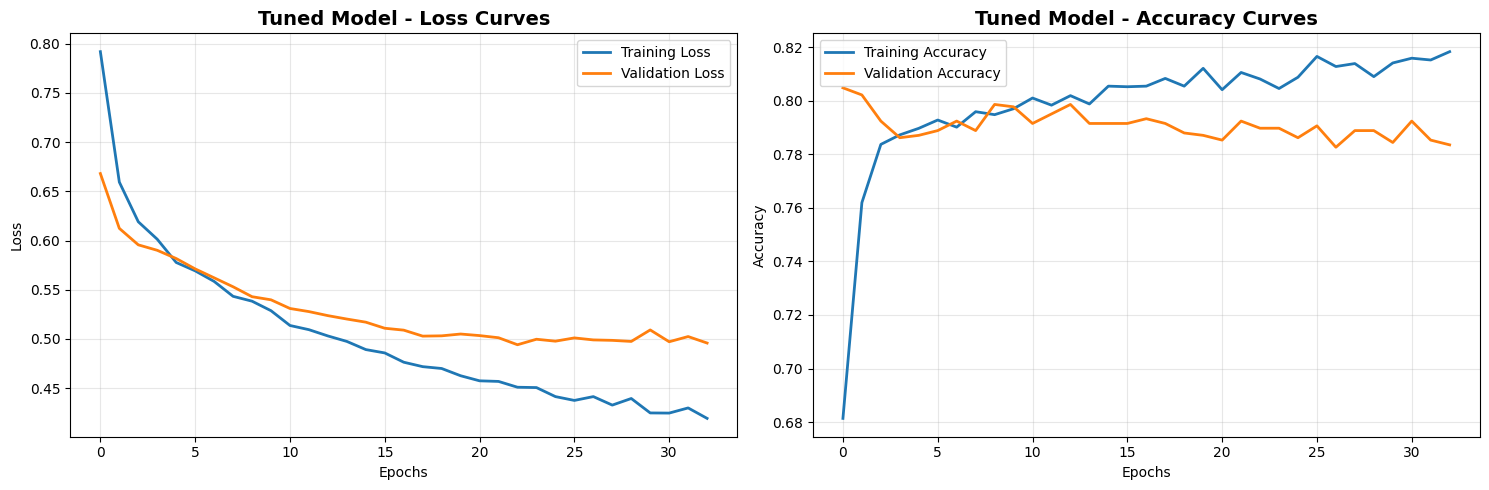


 BEFORE vs AFTER COMPARISON


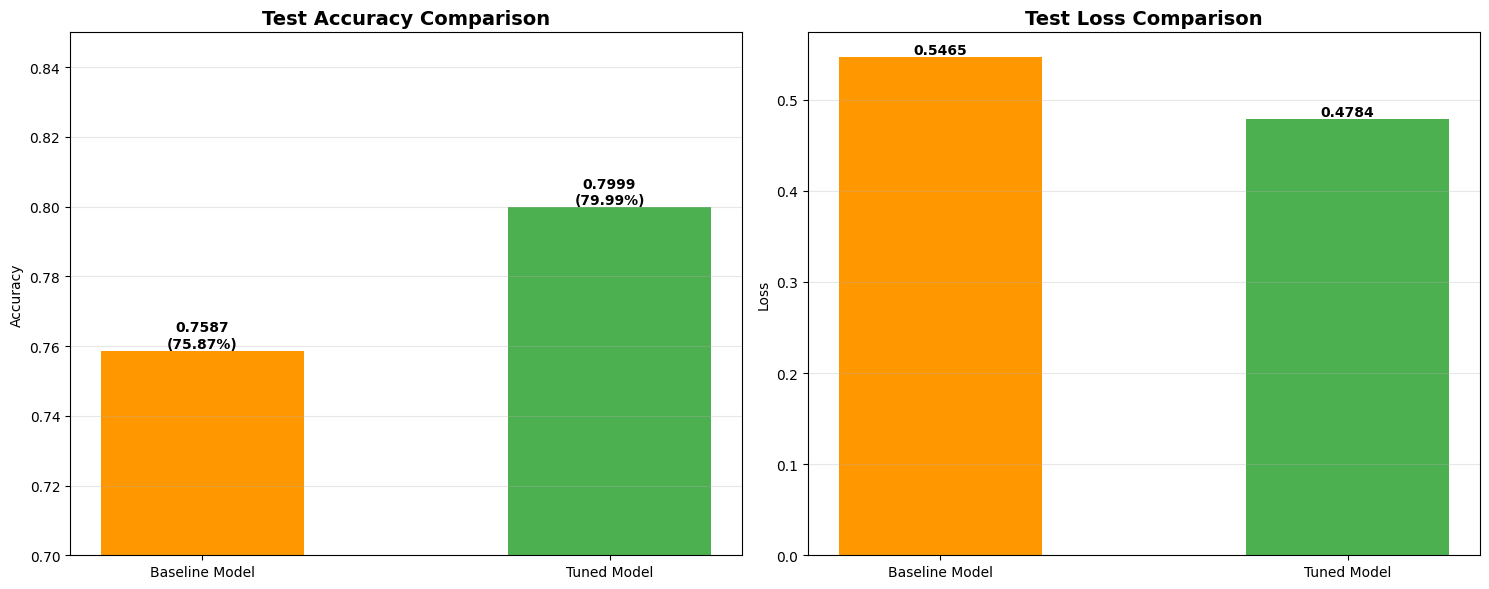


Model Performance Comparison:


,Model,Test Accuracy,Test Loss,Improvement
0,Baseline,0.7587,0.5465,-
1,Tuned,0.7999,0.4784,5.43%



 Tuned model improved accuracy by 5.43%

 Part 4 Complete: Model tuned and improved!


In [13]:
# ============================================
# PART 4: Model Tuning & Improvement
# ============================================

print("\n" + "="*60)
print("PART 4: MODEL TUNING & IMPROVEMENT")
print("="*60)

print("""
 Tuning Techniques Applied:
1. Dropout (0.3, 0.3, 0.2) - Prevents overfitting by randomly dropping neurons
2. Batch Normalization - Normalizes layer inputs for faster training
3. L2 Regularization (0.001) - Penalizes large weights to reduce overfitting
4. Early Stopping (patience=10) - Stops training when validation loss stops improving
5. Increased neurons (128, 64, 32) - More capacity for learning complex patterns
""")

def create_tuned_model(input_dim):
    """
    Create tuned neural network model with improvements
    """
    model = keras.Sequential([
        # Layer 1 with L2 regularization, BatchNorm, and Dropout
        layers.Dense(128, activation='relu', input_shape=(input_dim,),
                    kernel_regularizer=regularizers.l2(0.001), name='Dense_1'),
        layers.BatchNormalization(name='BatchNorm_1'),
        layers.Dropout(0.3, name='Dropout_1'),

        # Layer 2 with L2 regularization, BatchNorm, and Dropout
        layers.Dense(64, activation='relu',
                    kernel_regularizer=regularizers.l2(0.001), name='Dense_2'),
        layers.BatchNormalization(name='BatchNorm_2'),
        layers.Dropout(0.3, name='Dropout_2'),

        # Layer 3 with L2 regularization, BatchNorm, and Dropout
        layers.Dense(32, activation='relu',
                    kernel_regularizer=regularizers.l2(0.001), name='Dense_3'),
        layers.BatchNormalization(name='BatchNorm_3'),
        layers.Dropout(0.2, name='Dropout_3'),

        # Output layer
        layers.Dense(1, activation='sigmoid', name='Output')
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Create tuned model
tuned_model = create_tuned_model(X_train.shape[1])
print("\n Tuned Model Architecture:")
print("="*50)
tuned_model.summary()

# Train tuned model
print("\n Training Tuned Model...")
tuned_history = tuned_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate tuned model
tuned_test_loss, tuned_test_acc = tuned_model.evaluate(X_test, y_test, verbose=0)
print("\n" + "="*50)
print(" TUNED MODEL PERFORMANCE:")
print("="*50)
print(f" Test Accuracy: {tuned_test_acc:.4f} ({tuned_test_acc*100:.2f}%)")
print(f" Test Loss: {tuned_test_loss:.4f}")

# Plot tuned training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss curves
axes[0].plot(tuned_history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(tuned_history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Tuned Model - Loss Curves', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(tuned_history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(tuned_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('Tuned Model - Accuracy Curves', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Before/After Comparison
print("\n" + "="*50)
print(" BEFORE vs AFTER COMPARISON")
print("="*50)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart comparison
models = ['Baseline Model', 'Tuned Model']
accuracies = [baseline_test_acc, tuned_test_acc]
colors = ['#FF9800', '#4CAF50']

bars = axes[0].bar(models, accuracies, color=colors, width=0.5)
axes[0].set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0.7, 0.85])

for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{acc:.4f}\n({acc*100:.2f}%)', ha='center', va='bottom', fontweight='bold')

axes[0].grid(True, alpha=0.3, axis='y')

# Loss comparison
losses = [baseline_test_loss, tuned_test_loss]
bars = axes[1].bar(models, losses, color=colors, width=0.5)
axes[1].set_title('Test Loss Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Loss')

for bar, loss in zip(bars, losses):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{loss:.4f}', ha='center', va='bottom', fontweight='bold')

axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Comparison table
comparison_df = pd.DataFrame({
    'Model': ['Baseline', 'Tuned'],
    'Test Accuracy': [f'{baseline_test_acc:.4f}', f'{tuned_test_acc:.4f}'],
    'Test Loss': [f'{baseline_test_loss:.4f}', f'{tuned_test_loss:.4f}'],
    'Improvement': ['-', f'{((tuned_test_acc - baseline_test_acc)/baseline_test_acc)*100:.2f}%']
})
print("\nModel Performance Comparison:")
display(comparison_df)

improvement = ((tuned_test_acc - baseline_test_acc) / baseline_test_acc) * 100
print(f"\n Tuned model improved accuracy by {improvement:.2f}%")

print("\n Part 4 Complete: Model tuned and improved!")


PART 5: MODEL EVALUATION

 Making predictions on test set...
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

 Classification Report (Tuned Model):
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      1035
       Churn       0.65      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409


 Key Metrics Summary:
Accuracy:  0.7999 (79.99%)
Precision: 0.6474 (64.74%)
Recall:    0.5401 (54.01%)
F1-Score:  0.5889 (58.89%)


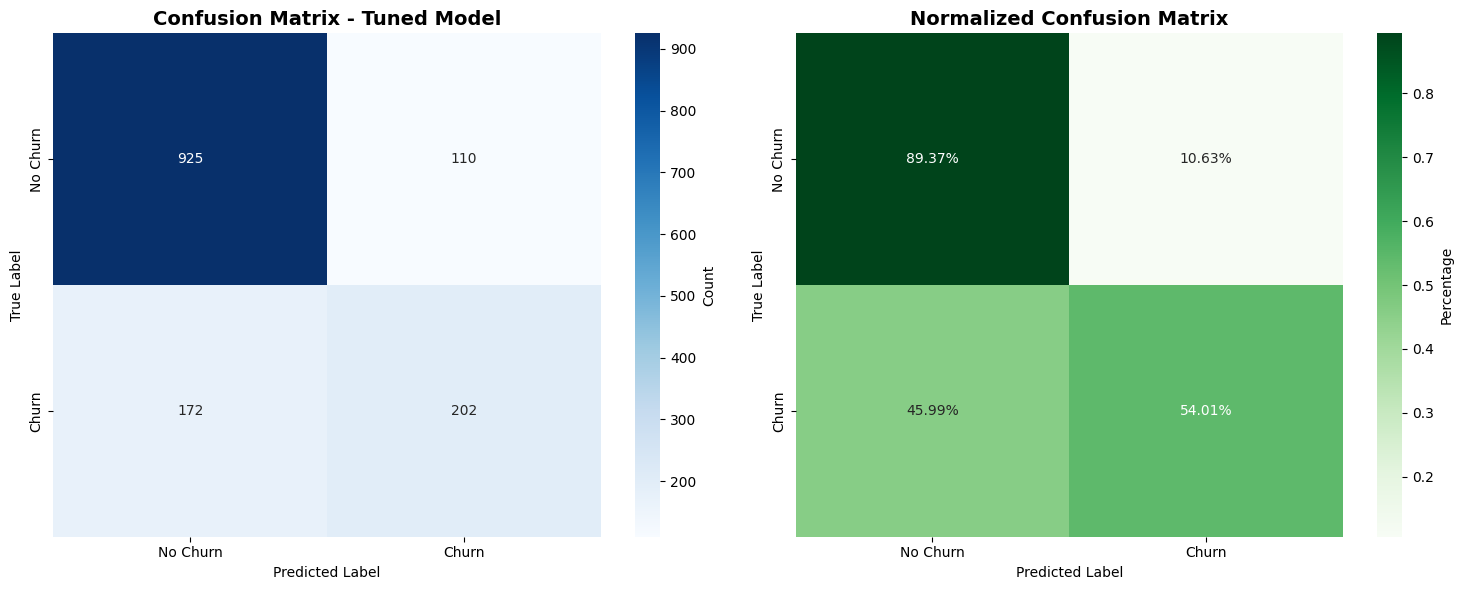


 IMPORTANT: Why Accuracy Alone is Misleading

The dataset is imbalanced with only 26.5% churned customers.
A naive model that predicts 'No Churn' for everyone would achieve:
- Accuracy: 73.5%
- But would miss ALL actual churners (recall = 0%)

Therefore, we need to look at:
• Precision: 64.7% - Of those predicted to churn, how many actually churned?
• Recall: 54.0% - Of all actual churners, how many did we correctly identify?
• F1-Score: 58.9% - Harmonic mean of precision and recall

These metrics provide a more complete picture of model performance
for the minority class (churners), which is often the class of interest
in business applications.

 Part 5 Complete: Model properly evaluated!


In [14]:
# ============================================
# PART 5: Model Evaluation & Confusion Matrix
# ============================================

print("\n" + "="*60)
print("PART 5: MODEL EVALUATION")
print("="*60)

# Predictions using best (tuned) model
print("\n Making predictions on test set...")
y_pred_proba = tuned_model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)

# Classification metrics
print("\n Classification Report (Tuned Model):")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

# Calculate metrics
precision = confusion_matrix(y_test, y_pred)[1][1] / (confusion_matrix(y_test, y_pred)[0][1] + confusion_matrix(y_test, y_pred)[1][1])
recall = confusion_matrix(y_test, y_pred)[1][1] / (confusion_matrix(y_test, y_pred)[1][0] + confusion_matrix(y_test, y_pred)[1][1])
f1 = 2 * (precision * recall) / (precision + recall)
accuracy = accuracy_score(y_test, y_pred)

print("\n Key Metrics Summary:")
print("="*60)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f} ({f1*100:.2f}%)")

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix - Tuned Model', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Normalized Confusion Matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            ax=axes[1], cbar_kws={'label': 'Percentage'})
axes[1].set_title('Normalized Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Explanation about accuracy limitations
print("\n IMPORTANT: Why Accuracy Alone is Misleading")
print("="*60)
print(f"""
The dataset is imbalanced with only {churn_counts['Yes']/len(df)*100:.1f}% churned customers.
A naive model that predicts 'No Churn' for everyone would achieve:
- Accuracy: {churn_counts['No']/len(df)*100:.1f}%
- But would miss ALL actual churners (recall = 0%)

Therefore, we need to look at:
• Precision: {precision*100:.1f}% - Of those predicted to churn, how many actually churned?
• Recall: {recall*100:.1f}% - Of all actual churners, how many did we correctly identify?
• F1-Score: {f1*100:.1f}% - Harmonic mean of precision and recall

These metrics provide a more complete picture of model performance
for the minority class (churners), which is often the class of interest
in business applications.
""")

print(" Part 5 Complete: Model properly evaluated!")


PART 6: SAVE MODEL, PREDICT & SHORT ANSWER

 Model saved as: telco_churn_model.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Model file downloaded: telco_churn_model.keras

 Testing with hypothetical customers...

 Customer 1 Profile (High-Risk):
----------------------------------------
• Contract: Month-to-month (risky)
• Tenure: 3 months (new customer)
• Internet: Fiber optic (expensive)
• Monthly Charges: $85.50 (high)
• No security/support services

 Prediction: CHURN
 Churn Probability: 81.28%

 Customer 2 Profile (Low-Risk):
----------------------------------------
• Contract: Two year (stable)
• Tenure: 60 months (loyal customer)
• Internet: DSL (affordable)
• Monthly Charges: $65.50 (moderate)
• Has all security/support services

 Prediction: NO CHURN
 Churn Probability: 1.92%


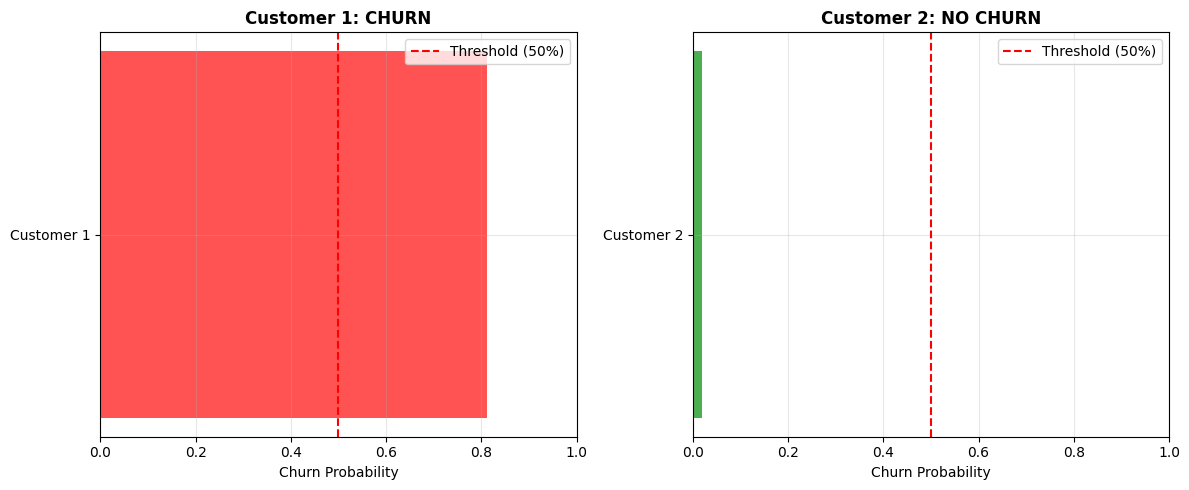


SHORT ANSWER: CNN vs RNN

 When to use CNN instead of Dense Network:
Convolutional Neural Networks (CNNs) are preferred when dealing with spatial data where 
local patterns and spatial hierarchies matter. CNNs use convolutional layers that can 
automatically detect features like edges, textures, and patterns regardless of their 
position in the input, making them highly efficient for grid-like data structures.
Example: Image classification for medical diagnosis (detecting tumors in X-rays or MRIs).

 When to use RNN instead of Dense Network:
Recurrent Neural Networks (RNNs) are designed for sequential data where order and temporal 
dependencies are crucial. They maintain internal memory through recurrent connections, 
allowing them to process sequences of varying lengths and capture relationships between 
elements over time. This makes them ideal for tasks where context from previous elements 
informs the understanding of current elements.
Example: Natural language processing tasks li

,Metric,Value
0,Dataset Size,7043 customers
1,Features Used,30 features
2,Churn Rate,26.5%
3,Baseline Accuracy,0.7587
4,Tuned Accuracy,0.7999
5,Improvement,5.43%
6,Model Saved,telco_churn_model.keras
7,Predictions Tested,2 customers



 All tasks completed successfully!
 Model file downloaded for submission
 Ready to submit with your notebook


In [15]:
# ============================================
# PART 6: Save Model, Predict & Short Answer
# ============================================

print("\n" + "="*60)
print("PART 6: SAVE MODEL, PREDICT & SHORT ANSWER")
print("="*60)

# Save the model
model_path = 'telco_churn_model.keras'
tuned_model.save(model_path)
print(f"\n Model saved as: {model_path}")

# Download the model file
from google.colab import files
files.download(model_path)
print(f" Model file downloaded: {model_path}")

# Function to load and predict
def predict_new_customer(model_path, customer_data, customer_name="Customer"):
    """
    Load saved model and predict churn for new customer

    Parameters:
    model_path: Path to saved model
    customer_data: Dictionary with customer information
    customer_name: Name/identifier for the customer

    Returns:
    Churn prediction and probability
    """
    # Load model
    loaded_model = keras.models.load_model(model_path)

    # Create DataFrame from customer data
    new_customer_df = pd.DataFrame([customer_data])

    # Apply same preprocessing
    # Binary encoding
    for col in binary_cols:
        if col in new_customer_df.columns:
            new_customer_df[col] = (new_customer_df[col] == 'Yes').astype(int)

    # One-hot encoding
    new_customer_encoded = pd.get_dummies(new_customer_df, columns=multi_cat_cols)

    # Ensure all columns from training are present
    for col in X.columns:
        if col not in new_customer_encoded.columns:
            new_customer_encoded[col] = 0

    # Reorder columns to match training data
    new_customer_encoded = new_customer_encoded[X.columns]

    # Scale numerical features
    new_customer_encoded[numerical_cols] = scaler.transform(new_customer_encoded[numerical_cols])

    # Predict
    prediction_proba = loaded_model.predict(new_customer_encoded, verbose=0)[0][0]
    prediction = "CHURN" if prediction_proba > 0.5 else "NO CHURN"

    return prediction, prediction_proba

# Test with hypothetical customers
print("\n Testing with hypothetical customers...")
print("="*60)

# Customer 1: High-risk customer
customer1 = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'No',
    'Dependents': 'No',
    'tenure': 3,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 85.5,
    'TotalCharges': 256.5
}

print("\n Customer 1 Profile (High-Risk):")
print("-" * 40)
print("• Contract: Month-to-month (risky)")
print("• Tenure: 3 months (new customer)")
print("• Internet: Fiber optic (expensive)")
print("• Monthly Charges: $85.50 (high)")
print("• No security/support services")

pred1, prob1 = predict_new_customer(model_path, customer1, "Customer 1")
print(f"\n Prediction: {pred1}")
print(f" Churn Probability: {prob1:.2%}")

# Visualize prediction
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Customer 1 prediction gauge
colors = ['#FF5252' if pred1 == 'CHURN' else '#4CAF50']
axes[0].barh(['Customer 1'], [prob1], color=colors)
axes[0].axvline(x=0.5, color='red', linestyle='--', label='Threshold (50%)')
axes[0].set_xlim([0, 1])
axes[0].set_xlabel('Churn Probability')
axes[0].set_title(f'Customer 1: {pred1}', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Customer 2: Low-risk customer
customer2 = {
    'gender': 'Male',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'Yes',
    'tenure': 60,
    'PhoneService': 'Yes',
    'MultipleLines': 'Yes',
    'InternetService': 'DSL',
    'OnlineSecurity': 'Yes',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'Yes',
    'TechSupport': 'Yes',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Two year',
    'PaperlessBilling': 'No',
    'PaymentMethod': 'Bank transfer (automatic)',
    'MonthlyCharges': 65.5,
    'TotalCharges': 3930.0
}

print("\n Customer 2 Profile (Low-Risk):")
print("-" * 40)
print("• Contract: Two year (stable)")
print("• Tenure: 60 months (loyal customer)")
print("• Internet: DSL (affordable)")
print("• Monthly Charges: $65.50 (moderate)")
print("• Has all security/support services")

pred2, prob2 = predict_new_customer(model_path, customer2, "Customer 2")
print(f"\n Prediction: {pred2}")
print(f" Churn Probability: {prob2:.2%}")

# Customer 2 prediction gauge
colors = ['#FF5252' if pred2 == 'CHURN' else '#4CAF50']
axes[1].barh(['Customer 2'], [prob2], color=colors)
axes[1].axvline(x=0.5, color='red', linestyle='--', label='Threshold (50%)')
axes[1].set_xlim([0, 1])
axes[1].set_xlabel('Churn Probability')
axes[1].set_title(f'Customer 2: {pred2}', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Short Answer: CNN vs RNN
print("\n" + "="*60)
print("SHORT ANSWER: CNN vs RNN")
print("="*60)

print("""
 When to use CNN instead of Dense Network:
Convolutional Neural Networks (CNNs) are preferred when dealing with spatial data where
local patterns and spatial hierarchies matter. CNNs use convolutional layers that can
automatically detect features like edges, textures, and patterns regardless of their
position in the input, making them highly efficient for grid-like data structures.
Example: Image classification for medical diagnosis (detecting tumors in X-rays or MRIs).

 When to use RNN instead of Dense Network:
Recurrent Neural Networks (RNNs) are designed for sequential data where order and temporal
dependencies are crucial. They maintain internal memory through recurrent connections,
allowing them to process sequences of varying lengths and capture relationships between
elements over time. This makes them ideal for tasks where context from previous elements
informs the understanding of current elements.
Example: Natural language processing tasks like sentiment analysis of customer reviews
or time series prediction for stock prices.

 Summary:
• CNN: Use for spatial pattern recognition (images, video frames)
• RNN: Use for sequential/temporal data (text, time series, audio)
• Dense: Use for tabular data with independent features (like this churn dataset)
""")

# Final Summary
print("\n" + "="*60)
print(" ASSIGNMENT COMPLETE! FINAL SUMMARY")
print("="*60)

summary_data = {
    'Metric': ['Dataset Size', 'Features Used', 'Churn Rate',
               'Baseline Accuracy', 'Tuned Accuracy', 'Improvement',
               'Model Saved', 'Predictions Tested'],
    'Value': [f'{df.shape[0]} customers', f'{X.shape[1]} features',
              f'{churn_counts["Yes"]/len(df)*100:.1f}%',
              f'{baseline_test_acc:.4f}', f'{tuned_test_acc:.4f}',
              f'{improvement:.2f}%', model_path, '2 customers']
}

summary_df = pd.DataFrame(summary_data)
display(summary_df)

print("\n All tasks completed successfully!")
print(" Model file downloaded for submission")
print(" Ready to submit with your notebook")